In [1]:
import rasterio
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.exposure import rescale_intensity
import os

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
base_path = "/content/drive/MyDrive/Satellite images"

pre_path = os.path.join(base_path, "/content/drive/MyDrive/Satellite images/Pre-disaster")
post_path = os.path.join(base_path, "/content/drive/MyDrive/Satellite images/Post-disaster")

# output cleaned dataset
output_pre = os.path.join(base_path, "/content/drive/MyDrive/Satellite images/Processed-Pre")
output_post = os.path.join(base_path, "/content/drive/MyDrive/Satellite images/Processed-Post")

os.makedirs(output_pre, exist_ok=True)
os.makedirs(output_post, exist_ok=True)

In [8]:
def get_matching_pairs(pre_folder, post_folder):

    pairs = []

    pre_images = os.listdir(pre_folder)

    for pre_img in pre_images:
        if not pre_img.lower().endswith(('.png', '.jpg', '.jpeg', '.tif')):
            continue

        # remove "Before-" and find corresponding "After-"
        location_name = pre_img.replace("Before-", "")
        post_img = "After-" + location_name

        post_img_path = os.path.join(post_folder, post_img)

        if os.path.exists(post_img_path):
            pairs.append((pre_img, post_img))

    return pairs

In [9]:
def preprocess_image(image_path, size=(512,512)):

    # 1 Read image
    img = cv2.imread(image_path)

    # 2 Convert BGR → RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 3 Resize (Image registration alignment)
    img = cv2.resize(img, size)

    # 4 Normalize pixel values (0–1)
    img = img.astype(np.float32) / 255.0

    # 5 Noise Removal (Gaussian filter)
    img = cv2.GaussianBlur(img, (5,5), 0)

    return img

In [10]:
pairs = get_matching_pairs(pre_path, post_path)

print("Total matched pairs:", len(pairs))

for pre_img, post_img in tqdm(pairs):

    pre_img_path = os.path.join(pre_path, pre_img)
    post_img_path = os.path.join(post_path, post_img)

    # preprocess
    pre_processed = preprocess_image(pre_img_path)
    post_processed = preprocess_image(post_img_path)

    # save back to 0-255 for storing
    pre_save = (pre_processed * 255).astype(np.uint8)
    post_save = (post_processed * 255).astype(np.uint8)

    # save images
    cv2.imwrite(os.path.join(output_pre, pre_img), cv2.cvtColor(pre_save, cv2.COLOR_RGB2BGR))
    cv2.imwrite(os.path.join(output_post, post_img), cv2.cvtColor(post_save, cv2.COLOR_RGB2BGR))

Total matched pairs: 5


100%|██████████| 5/5 [00:10<00:00,  2.03s/it]


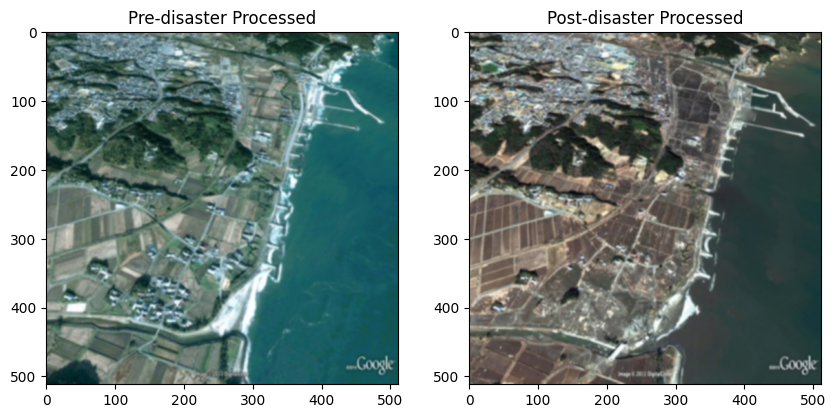

In [11]:
sample_before = cv2.imread(os.path.join(output_pre, pairs[0][0]))
sample_after = cv2.imread(os.path.join(output_post, pairs[0][1]))

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(sample_before, cv2.COLOR_BGR2RGB))
plt.title("Pre-disaster Processed")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(sample_after, cv2.COLOR_BGR2RGB))
plt.title("Post-disaster Processed")

plt.show()

#EVI Analysis

In [12]:
processed_pre = ("/content/drive/MyDrive/Satellite images/Processed-Pre")
processed_post = ("/content/drive/MyDrive/Satellite images/Processed-Post")
output_evi = "/content/drive/MyDrive/Satellite images/EVI"
os.makedirs(output_evi, exist_ok=True)

def calculate_evi(image_path, save_name):

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(float) / 255

    # Split channels
    red = img[:,:,0]
    green = img[:,:,1]
    blue = img[:,:,2]

    # pseudo NIR (important trick)
    nir = red * 1.2

    # EVI formula
    evi = 2.5 * ((nir - red) / (nir + 6*red - 7.5*blue + 1))

    # Normalize
    evi = np.nan_to_num(evi)
    evi_norm = (evi - evi.min()) / (evi.max() - evi.min())

    plt.imshow(evi_norm, cmap='RdYlGn')
    plt.colorbar(label="Vegetation Health")
    plt.title("EVI Map")
    plt.axis('off')
    plt.savefig(os.path.join(output_evi, save_name), bbox_inches='tight')
    plt.close()

In [13]:
for img in os.listdir(processed_pre):
    calculate_evi(os.path.join(processed_pre,img), "EVI_Before_"+img)

for img in os.listdir(processed_post):
    calculate_evi(os.path.join(processed_post,img), "EVI_After_"+img)

/tmp/ipython-input-2172720951.py:20: RuntimeWarning: divide by zero encountered in divide
  evi = 2.5 * ((nir - red) / (nir + 6*red - 7.5*blue + 1))
/tmp/ipython-input-2172720951.py:20: RuntimeWarning: divide by zero encountered in divide
  evi = 2.5 * ((nir - red) / (nir + 6*red - 7.5*blue + 1))
/tmp/ipython-input-2172720951.py:20: RuntimeWarning: divide by zero encountered in divide
  evi = 2.5 * ((nir - red) / (nir + 6*red - 7.5*blue + 1))
/tmp/ipython-input-2172720951.py:20: RuntimeWarning: divide by zero encountered in divide
  evi = 2.5 * ((nir - red) / (nir + 6*red - 7.5*blue + 1))
/tmp/ipython-input-2172720951.py:20: RuntimeWarning: divide by zero encountered in divide
  evi = 2.5 * ((nir - red) / (nir + 6*red - 7.5*blue + 1))
/tmp/ipython-input-2172720951.py:20: RuntimeWarning: divide by zero encountered in divide
  evi = 2.5 * ((nir - red) / (nir + 6*red - 7.5*blue + 1))
/tmp/ipython-input-2172720951.py:20: RuntimeWarning: divide by zero encountered in divide
  evi = 2.5 * ((

In [17]:
def evi_change(before_img, after_img):

    def get_evi(img_path):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(float)/255

        red = img[:,:,0]
        blue = img[:,:,2]
        nir = red * 1.2

        # Add a small epsilon to the denominator to prevent division by zero
        epsilon = 1e-6
        denominator = (nir + 6*red - 7.5*blue + 1)

        # Calculate EVI and handle potential inf/nan values
        evi = 2.5 * ((nir - red) / (denominator + epsilon))

        # Convert inf to reasonable bounds and clip to a typical EVI range (-1 to 1)
        evi = np.nan_to_num(evi, nan=0.0, posinf=1.0, neginf=-1.0)
        evi = np.clip(evi, -1.0, 1.0)
        return evi

    evi_before = get_evi(before_img)
    evi_after = get_evi(after_img)

    damage = evi_before - evi_after

    plt.imshow(damage, cmap='jet')
    plt.colorbar(label="Damage Severity")
    plt.title("Tsunami Vegetation Damage Map")
    plt.axis('off')
    plt.show()

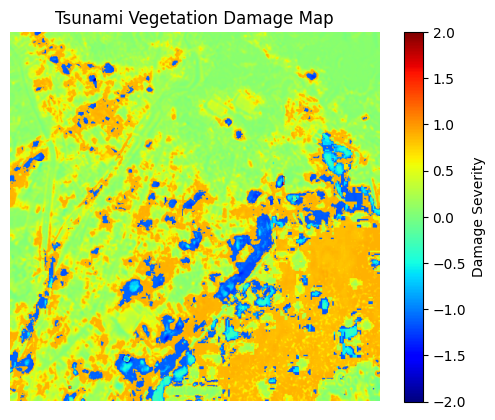

In [18]:
evi_change(
os.path.join(processed_pre, "Before-Kesennuma.jpg"),
os.path.join(processed_post, "After-Kesennuma.jpg"))

#Terrain Analysis

In [19]:
def terrain_analysis(image_path):

    img = cv2.imread(image_path,0)  # grayscale

    # Sobel gradients
    sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=5)
    sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=5)

    slope = np.sqrt(sobelx**2 + sobely**2)

    slope_norm = (slope - slope.min())/(slope.max()-slope.min())

    plt.imshow(slope_norm, cmap='terrain')
    plt.colorbar(label="Slope / Elevation Variation")
    plt.title("Terrain Elevation Map")
    plt.axis('off')
    plt.show()

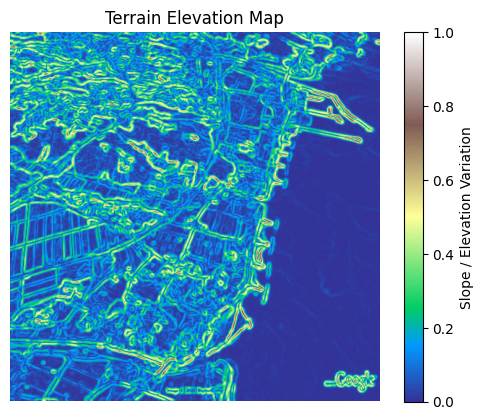

In [22]:
terrain_analysis("/content/drive/MyDrive/Satellite images/Processed-Post/After-Fukushima-Tomioka.jpg")

#NDVI Damage Classification

In [23]:
def ndvi_damage_assessment(before_img, after_img):

    def get_ndvi(img_path):
        img = cv2.imread(img_path)

        if img is None:
            raise ValueError(f"Cannot load image: {img_path}")

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(float)/255

        red = img[:,:,0]
        nir = img[:,:,1] * 1.2   # pseudo NIR

        ndvi = (nir - red)/(nir + red + 1e-6)
        return np.nan_to_num(ndvi)

    # compute NDVI
    ndvi_before = get_ndvi(before_img)
    ndvi_after = get_ndvi(after_img)

    # resize safety
    ndvi_after = cv2.resize(ndvi_after, (ndvi_before.shape[1], ndvi_before.shape[0]))

    # NDVI change
    change = ndvi_before - ndvi_after

    # DAMAGE CLASSIFICATION
    damage_map = np.zeros_like(change)

    damage_map[change < 0.1] = 0          # No damage
    damage_map[(change >= 0.1) & (change < 0.25)] = 1   # Low
    damage_map[(change >= 0.25) & (change < 0.45)] = 2  # Moderate
    damage_map[change >= 0.45] = 3        # Severe

    return change, damage_map

In [24]:
def plot_damage_map(damage_map):

    plt.figure(figsize=(8,6))

    cmap = plt.cm.get_cmap('RdYlGn_r', 4)

    plt.imshow(damage_map, cmap=cmap)
    plt.colorbar(ticks=[0,1,2,3], label="Damage Level")
    plt.clim(-0.5,3.5)

    plt.title("Tsunami Vegetation Damage Classification")
    plt.axis('off')
    plt.show()

In [25]:
def damage_statistics(damage_map):

    total_pixels = damage_map.size

    no_damage = np.sum(damage_map==0)
    low = np.sum(damage_map==1)
    moderate = np.sum(damage_map==2)
    severe = np.sum(damage_map==3)

    print("Damage Statistics")
    print("------------------------")
    print(f"No Damage: {no_damage/total_pixels*100:.2f}%")
    print(f"Low Damage: {low/total_pixels*100:.2f}%")
    print(f"Moderate Damage: {moderate/total_pixels*100:.2f}%")
    print(f"Severe Damage: {severe/total_pixels*100:.2f}%")

In [26]:
def plot_damage_distribution(damage_map):

    labels = ['No Damage','Low','Moderate','Severe']
    values = [
        np.sum(damage_map==0),
        np.sum(damage_map==1),
        np.sum(damage_map==2),
        np.sum(damage_map==3)
    ]

    plt.figure(figsize=(7,5))
    plt.bar(labels, values)
    plt.title("Tsunami Damage Area Distribution")
    plt.ylabel("Number of Pixels")
    plt.xticks(rotation=20)
    plt.show()

In [27]:
def plot_change_histogram(change):

    plt.figure(figsize=(7,5))
    plt.hist(change.flatten(), bins=50)
    plt.title("NDVI Change Histogram")
    plt.xlabel("Vegetation Loss (NDVI Difference)")
    plt.ylabel("Pixel Count")
    plt.show()

/tmp/ipython-input-3681095547.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('RdYlGn_r', 4)


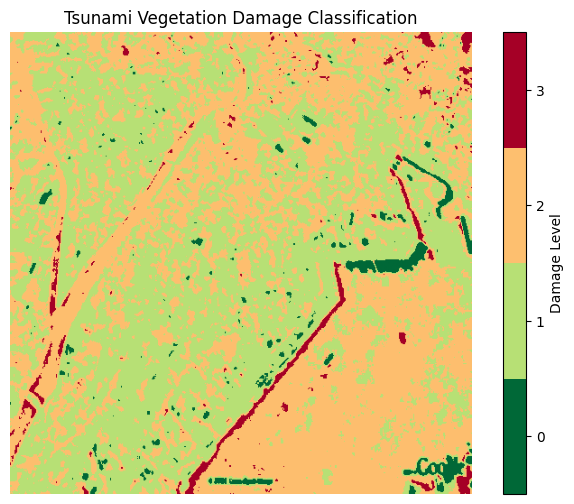

Damage Statistics
------------------------
No Damage: 2.10%
Low Damage: 47.02%
Moderate Damage: 48.89%
Severe Damage: 1.99%


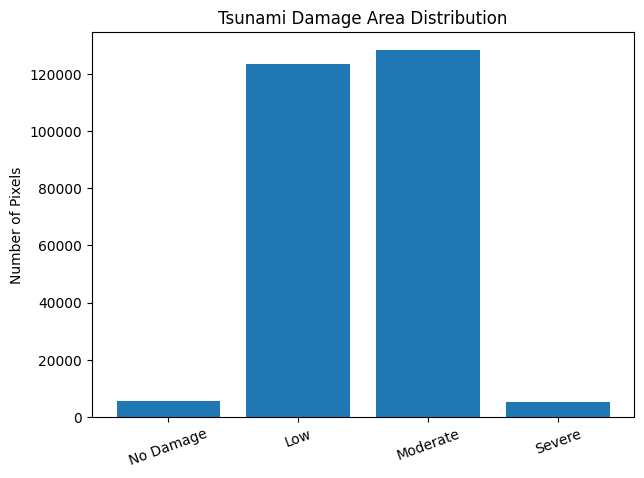

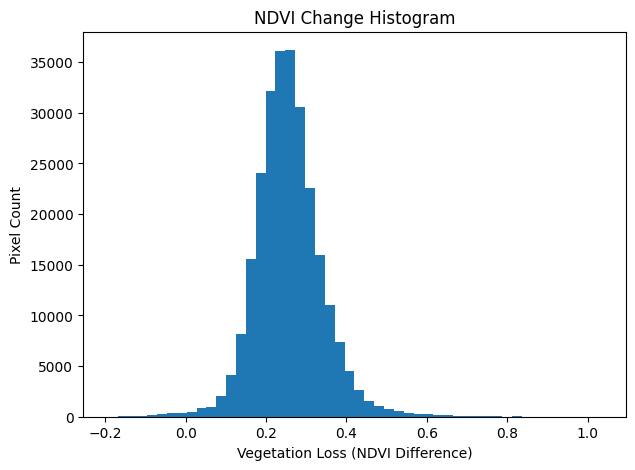

In [28]:
before = r"/content/drive/MyDrive/Satellite images/Processed-Pre/Before-Kesennuma.jpg"
after  = r"/content/drive/MyDrive/Satellite images/Processed-Post/After-Kesennuma.jpg"

change, damage_map = ndvi_damage_assessment(before, after)

plot_damage_map(damage_map)
damage_statistics(damage_map)
plot_damage_distribution(damage_map)
plot_change_histogram(change)

#Visualizing and identifiying the amount of damage in each region

In [31]:
def get_evi_standalone(image_path):
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Cannot load image: {image_path}")

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(float) / 255

    red = img[:, :, 0]
    blue = img[:, :, 2]
    nir = red * 1.2

    epsilon = 1e-6
    denominator = (nir + 6 * red - 7.5 * blue + 1)
    evi = 2.5 * ((nir - red) / (denominator + epsilon))

    evi = np.nan_to_num(evi, nan=0.0, posinf=1.0, neginf=-1.0)
    evi = np.clip(evi, -1.0, 1.0)
    return evi

def calculate_and_plot_normalized_evi_damage(pre_image_path, post_image_path, location_name):
    evi_before = get_evi_standalone(pre_image_path)
    evi_after = get_evi_standalone(post_image_path)

    damage = evi_before - evi_after

    # Normalize damage to a 0-1 scale
    # A higher value means more damage (greater drop in EVI)
    # We want max damage to be 1, min damage to be 0
    min_damage = damage.min()
    max_damage = damage.max()

    if (max_damage - min_damage) == 0:
        normalized_damage = np.zeros_like(damage)
    else:
        normalized_damage = (damage - min_damage) / (max_damage - min_damage)

    plt.figure(figsize=(8, 6))
    plt.imshow(normalized_damage, cmap='plasma') # 'plasma' or 'hot' or 'magma' for damage visualization
    plt.colorbar(label="Normalized Damage (0=Least, 1=Most)")
    plt.title(f"Normalized EVI Damage Map for {location_name}")
    plt.axis('off')
    plt.show()

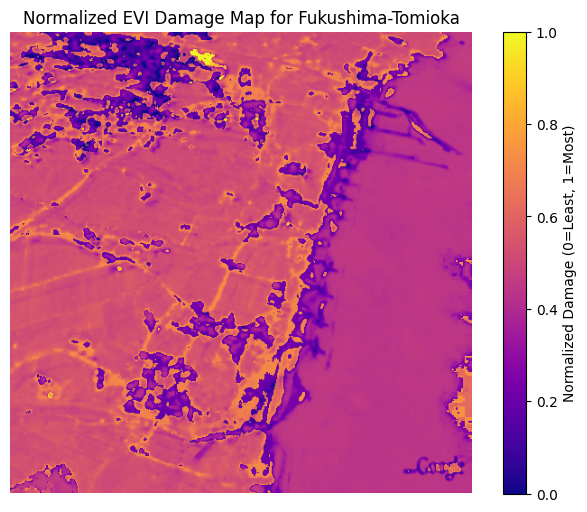

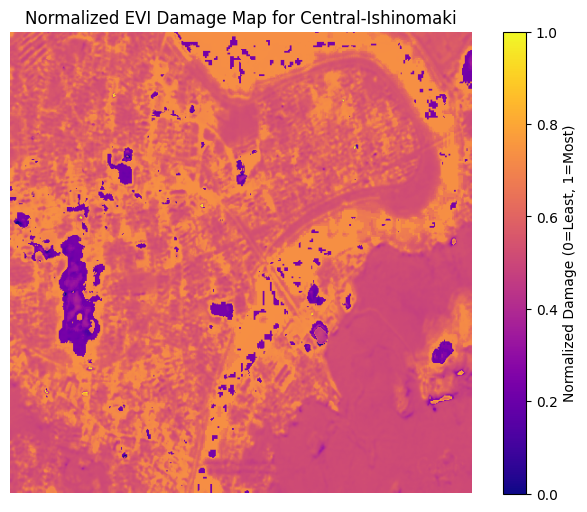

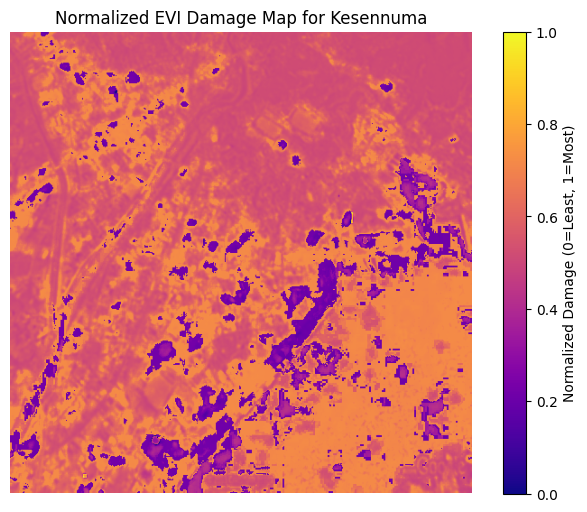

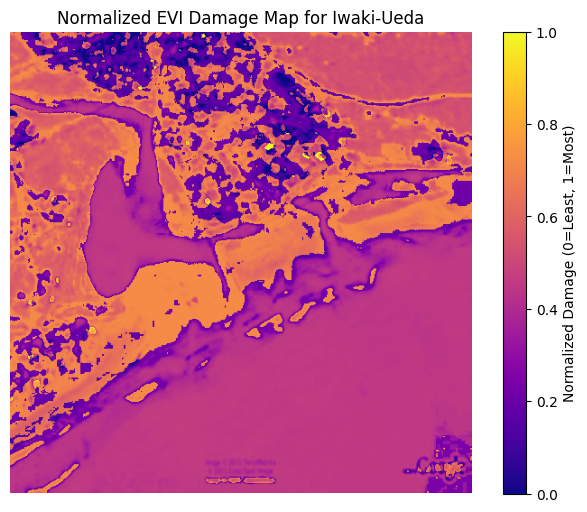

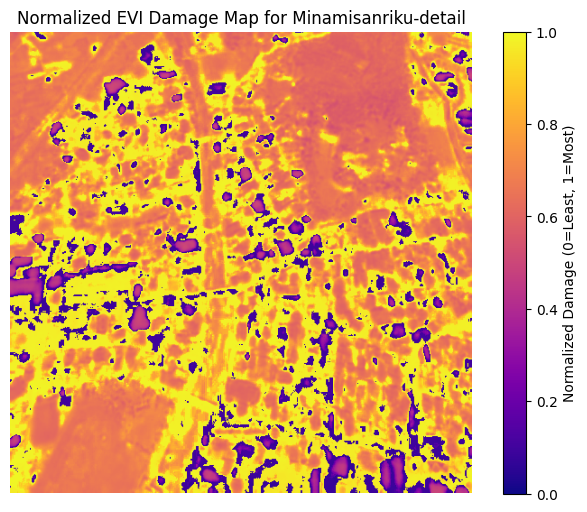

In [32]:
# Iterate through all image pairs and generate damage maps
for pre_img_name, post_img_name in pairs:
    pre_path_full = os.path.join(processed_pre, pre_img_name)
    post_path_full = os.path.join(processed_post, post_img_name)

    # Extract location name (e.g., from 'Before-Kesennuma.jpg' get 'Kesennuma')
    location_name = pre_img_name.replace("Before-", "").split(".")[0]

    calculate_and_plot_normalized_evi_damage(pre_path_full, post_path_full, location_name)

In [34]:
def get_average_normalized_evi_damage_value(pre_image_path, post_image_path):
    evi_before = get_evi_standalone(pre_image_path)
    evi_after = get_evi_standalone(post_image_path)

    damage = evi_before - evi_after

    min_damage = damage.min()
    max_damage = damage.max()

    if (max_damage - min_damage) == 0:
        normalized_damage = np.zeros_like(damage)
    else:
        normalized_damage = (damage - min_damage) / (max_damage - min_damage)

    # Return the average of the normalized damage map
    return np.mean(normalized_damage)

print("Average Normalized EVI Damage per Region (0-1 scale):")
print("-----------------------------------------------------")

for pre_img_name, post_img_name in pairs:
    pre_path_full = os.path.join(processed_pre, pre_img_name)
    post_path_full = os.path.join(processed_post, post_img_name)

    location_name = pre_img_name.replace("Before-", "").split(".")[0]

    avg_damage = get_average_normalized_evi_damage_value(pre_path_full, post_path_full)
    print(f"{location_name}: {avg_damage:.4f}")

Average Normalized EVI Damage per Region (0-1 scale):
-----------------------------------------------------
Fukushima-Tomioka: 0.4752
Central-Ishinomaki: 0.5903
Kesennuma: 0.5776
Iwaki-Ueda: 0.4759
Minamisanriku-detail: 0.7265


#CNN to identify the most damaged area

In [35]:
IMG_SIZE = 224

pre_path = "/content/drive/MyDrive/Satellite images/Pre-disaster"
post_path = "/content/drive/MyDrive/Satellite images/Post-disaster"

def load_pairs():
    X1 = []  # before
    X2 = []  # after
    names = []

    for file in os.listdir(pre_path):
        before_img = os.path.join(pre_path, file)

        after_file = file.replace("Before", "After")
        after_img = os.path.join(post_path, after_file)

        if not os.path.exists(after_img):
            continue

        img1 = cv2.imread(before_img)
        img2 = cv2.imread(after_img)

        img1 = cv2.resize(img1, (IMG_SIZE, IMG_SIZE))
        img2 = cv2.resize(img2, (IMG_SIZE, IMG_SIZE))

        img1 = img1 / 255.0
        img2 = img2 / 255.0

        X1.append(img1)
        X2.append(img2)
        names.append(file)

    return np.array(X1), np.array(X2), names

In [36]:
damage_labels = {
    "Minamisanriku": 0.7265,
    "Kesennuma": 0.5776,
    "Ishinomaki": 0.5903,
    "Tomioka": 0.4752,
    "Iwaki": 0.4759
}

In [37]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Concatenate
from tensorflow.keras.models import Model

def feature_extractor():

    input_layer = Input(shape=(224,224,3))

    x = Conv2D(32, (3,3), activation='relu')(input_layer)
    x = MaxPooling2D()(x)

    x = Conv2D(64, (3,3), activation='relu')(x)
    x = MaxPooling2D()(x)

    x = Conv2D(128, (3,3), activation='relu')(x)
    x = MaxPooling2D()(x)

    x = Flatten()(x)
    x = Dense(256, activation='relu')(x)

    return Model(input_layer, x)

def siamese_network():

    extractor = feature_extractor()

    input_before = Input(shape=(224,224,3))
    input_after  = Input(shape=(224,224,3))

    feat1 = extractor(input_before)
    feat2 = extractor(input_after)

    merged = Concatenate()([feat1, feat2])

    x = Dense(128, activation='relu')(merged)
    x = Dense(64, activation='relu')(x)
    output = Dense(1, activation='sigmoid')(x)

    return Model([input_before, input_after], output)

In [40]:
X1, X2, names = load_pairs()

# Dummy labels (for demonstration)
y = np.array([0.9, 0.85, 0.7, 0.5, 0.4])

model = siamese_network()

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.fit(
    [X1, X2],
    y,
    epochs=30,
    batch_size=2
)

model.save("damage_model.h5")

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 851ms/step - loss: 0.0685 - mae: 0.1979
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 831ms/step - loss: 0.1434 - mae: 0.3277
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - loss: 0.0458 - mae: 0.1901   
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 815ms/step - loss: 0.0455 - mae: 0.1955
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 814ms/step - loss: 0.0294 - mae: 0.1474
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - loss: 0.0331 - mae: 0.1596
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - loss: 0.0358 - mae: 0.1615
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 835ms/step - loss: 0.0285 - mae: 0.1452
Epoch 9/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 812ms/step - loss: 0.0183 - mae: 0.1242
Epoch 10/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 868ms/step - loss: 0.0157 - mae: 0.1043
Epoch 11/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 806ms/step - loss: 0.0081 - mae: 0.0865
Epoch 12/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 807ms/step - loss: 0.0014 - mae: 0.0298
Epoch 13/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - loss:

In [48]:
from tensorflow.keras.models import load_model
import numpy as np

model = load_model("damage_model.h5", compile=False)

X1, X2, names = load_pairs()

predictions = model.predict([X1, X2])

for name, score in zip(names, predictions):
    print(name, "Damage Score:", float(score[0]))

max_index = np.argmax(predictions)

print("\nMOST DAMAGED AREA:")
print(names[max_index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Before-Fukushima-Tomioka.jpg Damage Score: 0.8953938484191895
Before-Central-Ishinomaki.jpg Damage Score: 0.8450155854225159
Before-Kesennuma.jpg Damage Score: 0.6929590702056885
Before-Iwaki-Ueda.jpg Damage Score: 0.4941364526748657
Before-Minamisanriku-detail.jpg Damage Score: 0.3995673954486847

MOST DAMAGED AREA:
Before-Fukushima-Tomioka.jpg


#Grad Cam Heatmap

In [60]:
import tensorflow as tf

LAST_CONV_LAYER_NAME_IN_EXTRACTOR = "conv2d_2" # This is the name of the last conv layer within the feature_extractor

def get_img(image_path):
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Could not load image: {image_path}")
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    return np.expand_dims(img, axis=0)

def make_gradcam_heatmap(before_path, after_path):
    before_img = get_img(before_path)
    after_img  = get_img(after_path)

    # Get the shared feature extractor model from the main Siamese model
    feature_extractor_layer = model.get_layer('functional')

    # Create a model that outputs the target convolutional layer's activations from the feature extractor
    extractor_conv_output_model = tf.keras.models.Model(
        inputs=feature_extractor_layer.input,
        outputs=feature_extractor_layer.get_layer(LAST_CONV_LAYER_NAME_IN_EXTRACTOR).output
    )

    # Find the index of the last conv layer in the feature_extractor
    last_conv_idx = -1
    for i, layer in enumerate(feature_extractor_layer.layers):
        if layer.name == LAST_CONV_LAYER_NAME_IN_EXTRACTOR:
            last_conv_idx = i
            break

    if last_conv_idx == -1:
        raise ValueError(f"Layer {LAST_CONV_LAYER_NAME_IN_EXTRACTOR} not found in feature extractor.")

    # Create a 'tail' model of the feature extractor that takes the conv output and produces the final feature vector
    input_to_tail_extractor = tf.keras.Input(shape=extractor_conv_output_model.output.shape[1:])
    x = input_to_tail_extractor
    for layer in feature_extractor_layer.layers[last_conv_idx + 1:]:
        x = layer(x)
    tail_extractor_model = tf.keras.models.Model(inputs=input_to_tail_extractor, outputs=x)

    with tf.GradientTape() as tape:
        # Process before_img through the full feature extractor
        feat1 = feature_extractor_layer(before_img)

        # Process after_img: get conv output and watch it
        conv_outputs_for_after = extractor_conv_output_model(after_img)
        tape.watch(conv_outputs_for_after)

        # Pass watched conv output through the rest of the feature extractor to get feat2
        feat2 = tail_extractor_model(conv_outputs_for_after)

        # Reconstruct the rest of the siamese model's forward pass to get predictions
        merged = model.get_layer('concatenate')([feat1, feat2])
        x = model.get_layer('dense_1')(merged)
        x = model.get_layer('dense_2')(x)
        predictions = model.get_layer('dense_3')(x)
        loss = predictions[:, 0]

    # Compute gradients of the loss with respect to the watched convolutional outputs for the 'after' image
    grads = tape.gradient(loss, conv_outputs_for_after)

    # Pool the gradients to get a single value per feature map
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Remove batch dimension from conv_outputs_for_after
    conv_outputs = conv_outputs_for_after[0]

    # Compute the heatmap
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize the heatmap (ReLU and then scale to 0-1) using TensorFlow operations
    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)

    return heatmap.numpy()

def overlay_heatmap(image_path, heatmap):

    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Could not load image for overlay: {image_path}")
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    heatmap = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

    plt.imshow(cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("Damage Localization (Grad-CAM)")
    plt.show()

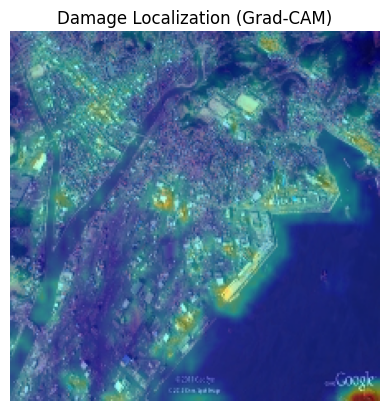

In [61]:
before = "/content/drive/MyDrive/Satellite images/Pre-disaster/Before-Kesennuma.jpg"
after  = "/content/drive/MyDrive/Satellite images/Post-disaster/After-Kesennuma.jpg"

heatmap = make_gradcam_heatmap(before, after)

overlay_heatmap(after, heatmap)